**Title: An Intelligent NLP Based Knowledge Extraction and Recommender System**

# Environment setup

## Packages installation

In [ ]:
!pip install nltk
!pip install wordcloud
!pip install rake-nltk

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


## Importing Packages

In [ ]:
import numpy as nmp
import nltk
import joblib
import pandas as pd
import io
import copy
from google.colab import files
from wordcloud import WordCloud
import matplotlib.pyplot as pplt
from rake_nltk import Rake
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity
from sklearn.metrics import mean_squared_error
nltk.download('stopwords')
nltk.download("punkt")
stopwords = nltk.corpus.stopwords.words('english')
rake_model = Rake()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Loading dataset

In [ ]:
uploaded_file = files.upload()
df_movie_data= pd.read_csv(io.BytesIO(uploaded_file['Movie_data.csv']), sep=',')

Saving Movie_data.csv to Movie_data.csv


# Exploratory Data Analysis (EDA)

In [ ]:
df_EDA = copy.deepcopy(df_movie_data)

In [ ]:
df_EDA.head(5)

,Unnamed: 0,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,"['crime', 'drama']",['US'],NaN,tt0075314,8.3,795222.0,27.612,8.2
2,2,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['comedy', 'fantasy']",['GB'],NaN,tt0071853,8.2,530877.0,18.216,7.8
3,3,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,['comedy'],['GB'],NaN,tt0079470,8.0,392419.0,17.505,7.8
4,4,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,['horror'],['US'],NaN,tt0070047,8.1,391942.0,95.337,7.7


In [ ]:
df_EDA.tail(5)

,Unnamed: 0,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
5747,5801,tm1014599,Fine Wine,MOVIE,A beautiful love story that can happen between...,2021,NaN,100,"['romance', 'drama']",['NG'],NaN,tt13857480,6.9,39.0,0.966,NaN
5748,5802,tm1108171,Edis Starlight,MOVIE,Rising star Edis's career journey with ups and...,2021,NaN,74,"['music', 'documentation']",[],NaN,NaN,NaN,NaN,1.036,8.5
5749,5803,tm1045018,Clash,MOVIE,A man from Nigeria returns to his family in Ca...,2021,NaN,88,"['family', 'drama']","['NG', 'CA']",NaN,tt14620732,6.5,32.0,0.709,NaN
5750,5804,tm1098060,Shadow Parties,MOVIE,A family faces destruction in a long-running c...,2021,NaN,116,"['action', 'thriller']",[],NaN,tt10168094,6.2,9.0,2.186,NaN
5751,5805,ts271048,Mighty Little Bheem: Kite Festival,SHOW,"With winter behind them, Bheem and his townspe...",2021,NaN,0,"['family', 'comedy', 'animation']",[],1.0,tt13711094,8.8,16.0,0.979,10.0


In [ ]:
df_EDA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            5752 non-null   int64  
 1   id                    5752 non-null   object 
 2   title                 5751 non-null   object 
 3   type                  5752 non-null   object 
 4   description           5734 non-null   object 
 5   release_year          5752 non-null   int64  
 6   age_certification     3163 non-null   object 
 7   runtime               5752 non-null   int64  
 8   genres                5752 non-null   object 
 9   production_countries  5752 non-null   object 
 10  seasons               2022 non-null   float64
 11  imdb_id               5313 non-null   object 
 12  imdb_score            5234 non-null   float64
 13  imdb_votes            5218 non-null   float64
 14  tmdb_popularity       5661 non-null   float64
 15  tmdb_score           

In [ ]:
types = df_EDA.groupby('type').size().reset_index().rename(columns = {0:'counts'})
types

,type,counts
0,MOVIE,3730
1,SHOW,2022


# Data Vizualization

## Pie chart- types

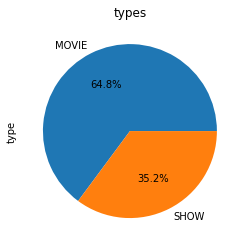

In [ ]:
df_EDA.type.value_counts().plot.pie(autopct='%1.1f%%',)
pplt.title('types')
pplt.show()

## wordcloud- helper function

In [ ]:
def generate_wordcloud(text_data):
    text_wordcloud = WordCloud(stopwords=stopwords,background_color='white').generate(str(text_data))
    figure = pplt.figure(1, figsize=(10, 10))
    figure.subplots_adjust(top=2.1)
    pplt.axis('off')
    pplt.imshow(text_wordcloud)

## Wordcloud - Movies

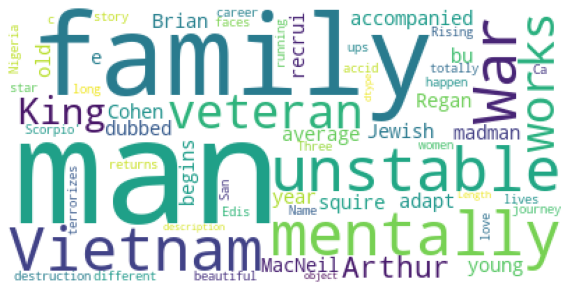

In [ ]:
df_movies = df_EDA[df_EDA['type']== 'MOVIE']
generate_wordcloud(df_movies['description'])

## Wordcloud - Shows

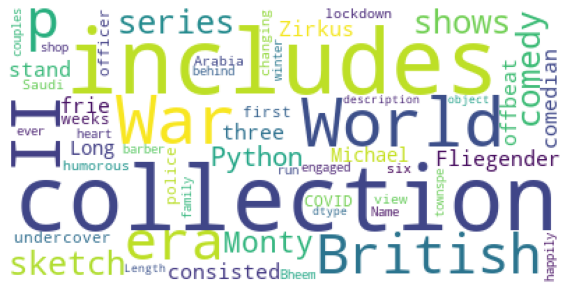

In [ ]:
df_shows = df_EDA[df_EDA['type']== 'SHOW']
generate_wordcloud(df_shows['description'])

## Wordcloud - Title

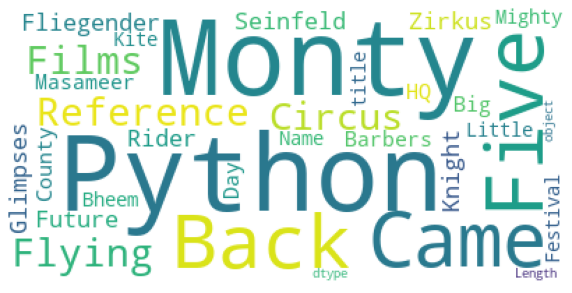

In [ ]:
generate_wordcloud(df_shows['title'])

## Wordcloud - Genres

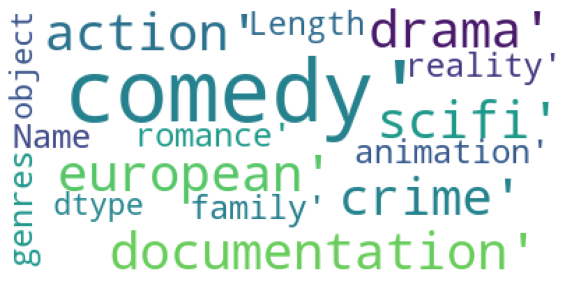

In [ ]:
generate_wordcloud(df_shows['genres'])

# Data Pre-processing



In [ ]:
def generate_N_grams(ex_taken,ngram=1):
  words=[word for word in ex_taken.split(" ") if word not in set(stopwords)]
  print("Sentence after removing stopwords:",words)
  temp=zip(*[words[i:] for i in range(0,ngram)])
  ans=[' '.join(ngram) for ngram in temp]
  return ans

In [ ]:
sample_text = df_EDA['description'].head(1)
sample_text

0    This collection includes 12 World War II-era p...
Name: description, dtype: object

In [ ]:
sample_text = df_EDA['description'].head(1)
generate_N_grams(str(sample_text),1)

Sentence after removing stopwords: ['0', '', '', '', 'This', 'collection', 'includes', '12', 'World', 'War', 'II-era', 'p...\nName:', 'description,', 'dtype:', 'object']


['0',
 '',
 '',
 '',
 'This',
 'collection',
 'includes',
 '12',
 'World',
 'War',
 'II-era',
 'p...\nName:',
 'description,',
 'dtype:',
 'object']


# Modelling




## TF-IDF based recommender

In [ ]:
df_tf_idf_movies = copy.deepcopy(df_movie_data)
df_tf_idf_movies = df_tf_idf_movies.drop_duplicates(subset='title', keep="first")
TFIDF = TfidfVectorizer(stop_words = 'english')
df_tf_idf_movies['description'] = df_tf_idf_movies['description'].fillna('')
TFIDF_matrix = TFIDF.fit_transform(df_tf_idf_movies['description'])

In [ ]:
joblib.dump(TFIDF_matrix, "tfidf_matrix.pkl")

['tfidf_matrix.pkl']

## Count vectorizer based recommender

In [ ]:
def extract_rake_keywords(input_text):
    rake_model.extract_keywords_from_text(input_text)
    rake_model.get_ranked_phrases_with_scores()
    key_words_dict_scores = rake_model.get_word_degrees()
    filtered_text = list(key_words_dict_scores.keys())
    return " ".join(filtered_text)

In [ ]:
def generate_combined_input(rowData):
  input_type = rowData['type'].lower()
  input_genre =  (" ".join(eval(rowData['genres']))).lower()
  input_description = extract_rake_keywords(rowData['description']).lower()
  return "'"+str(input_type)+" "+str(input_genre)+" "+str(input_description)+"'"

In [ ]:
df_count_vectorizer_movies = copy.deepcopy(df_movie_data)
df_count_vectorizer_movies = df_count_vectorizer_movies.drop_duplicates(subset='title', keep="first")
df_count_vectorizer_movies.fillna('',inplace=True)
df_count_vectorizer_movies['combined_input'] = df_count_vectorizer_movies.apply (lambda row: generate_combined_input(row),axis=1)
count_vectorizer = CountVectorizer(analyzer='word',ngram_range=(1, 2),min_df=0, stop_words='english')
count_vectorizer_matrix = count_vectorizer.fit_transform(df_count_vectorizer_movies['combined_input'])

In [ ]:
joblib.dump(count_vectorizer_matrix, "count_matrix.pkl")

['count_matrix.pkl']

## Weighted ratings based recommendations

In [ ]:
def return_weighted_ratings(rowData, mean_score, percentile90_votes):
  weighted_rating = ((rowData['imdb_votes']/(rowData['imdb_votes']+percentile90_votes) * rowData['imdb_score']) + (percentile90_votes/(percentile90_votes+rowData['imdb_votes']) * mean_score))
  return weighted_rating

In [ ]:
df_weighted_ratings_movies = copy.deepcopy(df_movie_data)
mean_score = df_weighted_ratings_movies['imdb_score'].mean()
percentile_90_votes = df_weighted_ratings_movies['imdb_votes'].quantile(0.9)
df_weighted_ratings_movies['weighted_ratings'] = df_weighted_ratings_movies.apply(lambda row: return_weighted_ratings(row,mean_score,percentile_90_votes), axis=1)
df_weighted_ratings_movies = df_weighted_ratings_movies.sort_values('weighted_ratings', ascending=False)
df_weighted_ratings_movies[['title','type','imdb_votes','imdb_score','weighted_ratings']].head(5)

,title,type,imdb_votes,imdb_score,weighted_ratings
243,Breaking Bad,SHOW,1727694.0,9.5,9.419089
259,Avatar: The Last Airbender,SHOW,297336.0,9.3,8.912434
260,Inception,MOVIE,2268288.0,8.8,8.752611
108,Forrest Gump,MOVIE,1994599.0,8.8,8.746263
914,Attack on Titan,SHOW,325381.0,9.0,8.680397


# Evaluation metrics

## TFIDF based recommender

In [2]:
df_eval_tf_idf_movies = copy.deepcopy(df_movie_data)
df_eval_tf_idf_movies = df_eval_tf_idf_movies.drop_duplicates(subset='title', keep="first")
movie_indices = pd.Series(df_eval_tf_idf_movies.index, index=df_eval_tf_idf_movies['title'])
tfidf_cosine_similarities = linear_kernel(TFIDF_matrix, TFIDF_matrix)
df_eval_tf_idf_movies[['Recommended_movie','Recommended_type','Recommended_genres','Recommended_movie_description','Recommended_movie_rating']] = df_eval_tf_idf_movies['title'].apply(lambda title: df_eval_tf_idf_movies.iloc[[index_similarities[0] for index_similarities in sorted(list(enumerate(tfidf_cosine_similarities[movie_indices[title]])), key=lambda row: row[1], reverse=True)][1]][['title','type','genres','description','imdb_score']])
df_eval_tf_idf_movies = df_eval_tf_idf_movies[['id','title','type','genres','description','imdb_score','Recommended_movie','Recommended_type','Recommended_genres','Recommended_movie_description','Recommended_movie_rating']]
df_eval_tf_idf_movies.dropna(subset=['imdb_score','Recommended_movie_rating'],inplace=True)

NameError: name 'copy' is not defined

In [ ]:
df_eval_tf_idf_movies.head(1)

In [ ]:
RMSE = nmp.sqrt(mean_squared_error(df_eval_tf_idf_movies['imdb_score'],df_eval_tf_idf_movies['Recommended_movie_rating']))
print("RMSE error for recommendations using TFIDF based recommender: ",RMSE,)

In [ ]:
MAE = nmp.mean(nmp.absolute(df_eval_tf_idf_movies['imdb_score']-df_eval_tf_idf_movies['Recommended_movie_rating']))
print("MAE error for recommendations using TFIDF based recommender: ",MAE)

## Count vectorizer based recommender

In [ ]:
df_eval_count_vectorizer_movies = copy.deepcopy(df_movie_data)
df_eval_count_vectorizer_movies = df_eval_count_vectorizer_movies.drop_duplicates(subset='title', keep="first")
movie_indices = pd.Series(df_eval_count_vectorizer_movies.index, index=df_eval_count_vectorizer_movies['title'])
count_vectorizer_cosine_similarities = linear_kernel(count_vectorizer_matrix, count_vectorizer_matrix)
df_eval_count_vectorizer_movies[['Recommended_movie','Recommended_type','Recommended_genres','Recommended_movie_description','Recommended_movie_rating']] = df_eval_count_vectorizer_movies['title'].apply(lambda title: df_eval_count_vectorizer_movies.iloc[[index_similarities[0] for index_similarities in sorted(list(enumerate(count_vectorizer_cosine_similarities[movie_indices[title]])), key=lambda row: row[1], reverse=True)][1]][['title','type','genres','description','imdb_score']])
df_eval_count_vectorizer_movies = df_eval_count_vectorizer_movies[['id','title','type','genres','description','imdb_score','Recommended_movie','Recommended_type','Recommended_genres','Recommended_movie_description','Recommended_movie_rating']]
df_eval_count_vectorizer_movies.dropna(subset=['imdb_score','Recommended_movie_rating'],inplace=True)

/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [ ]:
df_eval_count_vectorizer_movies.head(1)

,id,title,type,genres,description,imdb_score,Recommended_movie,Recommended_type,Recommended_genres,Recommended_movie_description,Recommended_movie_rating
1,tm84618,Taxi Driver,MOVIE,"['crime', 'drama']",A mentally unstable Vietnam War veteran works ...,8.3,White Girl,MOVIE,"['drama', 'horror', 'crime']","Summer, New York City. A college girl falls ha...",5.7


In [ ]:
RMSE = nmp.sqrt(mean_squared_error(df_eval_count_vectorizer_movies['imdb_score'],df_eval_count_vectorizer_movies['Recommended_movie_rating']))
print("RMSE error for recommendations using countvectorizer based recommender: ",RMSE,)

RMSE error for recommendations using countvectorizer based recommender:  1.430530731814461


In [ ]:
MAE = nmp.mean(nmp.absolute(df_eval_count_vectorizer_movies['imdb_score']-df_eval_count_vectorizer_movies['Recommended_movie_rating']))
print("MAE error for recommendations using countvectorizer based recommender: ",MAE)

MAE error for recommendations using countvectorizer based recommender:  1.094826907946499


# Sample recommendations

In [ ]:
def get_recommendations(filtered_movie_data,movie_title, vectorized_matrix):
    movie_indices = pd.Series(filtered_movie_data.index, index=filtered_movie_data['title'])
    input_movie_index = movie_indices[movie_title]
    cosine_similarities = linear_kernel(vectorized_matrix, vectorized_matrix)
    similarity_scores = list(enumerate(cosine_similarities[input_movie_index]))
    sorted_similarirty_scores = sorted(similarity_scores, key=lambda row: row[1], reverse=True)
    recommended_similarity_scores = sorted_similarirty_scores[1:6]
    recommended_movie_indices = [tuple_scores[0] for tuple_scores in recommended_similarity_scores]
    return filtered_movie_data[['title','type','genres','description', 'imdb_score']].iloc[recommended_movie_indices].astype(str).sort_values('imdb_score', ascending=False)

In [ ]:
def improved_recommendations(filtered_movie_data,movie_title, vectorized_matrix):
    movie_indices = pd.Series(filtered_movie_data.index, index=filtered_movie_data['title'])
    input_movie_index = movie_indices[movie_title]
    cosine_similarities = linear_kernel(vectorized_matrix, vectorized_matrix)
    similarity_scores = list(enumerate(cosine_similarities[input_movie_index]))
    sorted_similarirty_scores = sorted(similarity_scores, key=lambda row: row[1], reverse=True)
    recommended_similarity_scores = sorted_similarirty_scores[1:6]
    recommended_movie_indices = [tuple_scores[0] for tuple_scores in recommended_similarity_scores]
    mean_score = filtered_movie_data['imdb_score'].mean()
    percentile_90_votes = filtered_movie_data['imdb_votes'].quantile(0.9)
    filtered_movie_data['weighted_ratings'] = filtered_movie_data.apply(lambda row: return_weighted_ratings(row,mean_score,percentile_90_votes), axis=1)
    return filtered_movie_data[['title','type','genres','description', 'imdb_score','weighted_ratings']].iloc[recommended_movie_indices].astype(str).sort_values('weighted_ratings', ascending=False)[['title','type','genres','description', 'imdb_score']]

In [ ]:
df_testing = copy.deepcopy(df_movie_data)
df_testing = df_testing.drop_duplicates(subset='title', keep="first")


## TFIDF vectorizer recommendations

In [ ]:
uploaded_file = files.upload()
TFIDF_matrix= joblib.load(io.BytesIO(uploaded_file["tfidf_matrix.pkl"]))


Saving tfidf_matrix.pkl to tfidf_matrix (1).pkl


In [ ]:
tfidf_based_recommendations = get_recommendations(df_testing,'The Mansion', TFIDF_matrix)
tfidf_based_recommendations

,title,type,genres,description,imdb_score
4810,Midnight Mass,SHOW,"['action', 'drama', 'fantasy', 'horror', 'scifi']",An isolated island community experiences mirac...,7.7
3525,Black Space,SHOW,"['crime', 'drama', 'thriller']",An ordinary morning at a small-town High Schoo...,6.7
5241,Elite Short Stories: Phillipe Caye Felipe,SHOW,"['comedy', 'drama', 'romance']","Away from school, during the winter holidays, ...",6.2
5188,Elite Short Stories: Patrick,SHOW,"['comedy', 'drama']","Away from school, during the winter holidays, ...",6.1
4930,No One Gets Out Alive,MOVIE,"['thriller', 'horror', 'drama']",An immigrant in search of the American dream i...,5.3


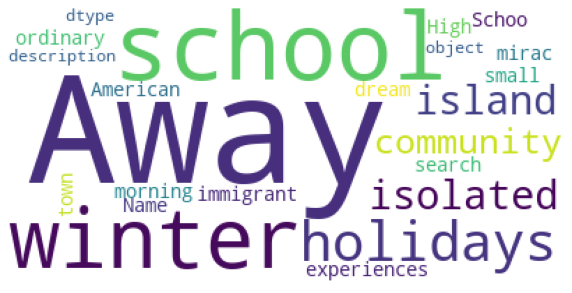

In [ ]:
generate_wordcloud(tfidf_based_recommendations['description'])

## Count vectorizer recommendations

In [ ]:
uploaded_file = files.upload()
count_vectorizer_matrix = joblib.load(io.BytesIO(uploaded_file["count_matrix.pkl"]))
#count_vectorizer_matrix = joblib.load("count_matrix.pkl")

In [ ]:
count_vectorizer_based_recommendations = get_recommendations(df_testing,'The Mansion', count_vectorizer_matrix)
count_vectorizer_based_recommendations

In [ ]:
improved_count_vectorizer_based_recommendations = improved_recommendations(df_testing,'The Mansion', count_vectorizer_matrix)
improved_count_vectorizer_based_recommendations

In [ ]:
count_vectorizer_based_recommendations['combined_input'] = count_vectorizer_based_recommendations.apply (lambda row: generate_combined_input(row),axis=1)
generate_wordcloud(count_vectorizer_based_recommendations['combined_input'])